In [ ]:
!pip install tensorflow=='2.15' --quiet

## Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (Conv2D, BatchNormalization, ReLU, Add,
                                     GlobalAveragePooling2D, Dense, Input,
                                     Concatenate, Layer, Maximum, Dropout, Multiply)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import ImageFile

In [ ]:
import keras
from IPython.display import Image, display
import matplotlib as mpl
import cv2
import tqdm

## Model Parameters

In [ ]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
CHANNELS = 3
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 200
N_EPOCHS = 30
LR = 1e-3

VALUE_DT = 0.2
PATH_DIR = ''

ImageFile.LOAD_TRUNCATED_IMAGES = True

## Model Functions

In [ ]:
class RGBtoHSV(Layer):
    def __init__(self, **kwargs):
        super(RGBtoHSV, self).__init__(**kwargs)

    def call(self, inputs):
        return tf.image.rgb_to_hsv(inputs)

    def get_config(self):
        config = super(RGBtoHSV, self).get_config()
        return config

class RGBtoYCbCr(Layer):
    def __init__(self, **kwargs):
        super(RGBtoYCbCr, self).__init__(**kwargs)

    def call(self, inputs):

        rgb_to_ycbcr_kernel = tf.constant([[0.299, 0.587, 0.114],
                                           [-0.1687, -0.3313, 0.5],
                                           [0.5, -0.4187, -0.0813]])
        offset = tf.constant([0, 128/255, 128/255], dtype=tf.float32)
        ycbcr = tf.tensordot(inputs, rgb_to_ycbcr_kernel, axes=[[3], [1]]) + offset

        return ycbcr

    def get_config(self):
        config = super(RGBtoYCbCr, self).get_config()
        return config

In [ ]:
class FuzzyPooling(Layer):
    def __init__(self, pool_size=(2, 2), strides=None, padding='VALID', fuzzy_k=2, **kwargs):
        super(FuzzyPooling, self).__init__(**kwargs)
        self.pool_size = pool_size
        self.strides = strides if strides is not None else pool_size
        self.padding = padding.upper()
        self.fuzzy_k = fuzzy_k

    def call(self, inputs):

        patches = tf.image.extract_patches(
            images=inputs,
            sizes=[1, self.pool_size[0], self.pool_size[1], 1],
            strides=[1, self.strides[0], self.strides[1], 1],
            rates=[1, 1, 1, 1],
            padding=self.padding
        )

        batch_size = tf.shape(inputs)[0]
        new_height = tf.shape(patches)[1]
        new_width = tf.shape(patches)[2]
        channels = inputs.shape[-1]
        patch_dim = self.pool_size[0] * self.pool_size[1]

        patches = tf.reshape(patches, [batch_size, new_height, new_width, channels, patch_dim])


        max_vals = tf.reduce_max(patches, axis=-1, keepdims=True)
        min_vals = tf.reduce_min(patches, axis=-1, keepdims=True)
        denom = max_vals - min_vals + 1e-6

        membership = 1 - tf.abs(patches - max_vals) / denom
        membership = tf.pow(membership, self.fuzzy_k)

        numerator = tf.reduce_sum(patches * membership, axis=-1)
        denominator = tf.reduce_sum(membership, axis=-1) + 1e-6
        fuzzy_pool = numerator / denominator

        return fuzzy_pool

    def compute_output_shape(self, input_shape):

        if self.padding == 'VALID':
            out_height = (input_shape[1] - self.pool_size[0]) // self.strides[0] + 1
            out_width = (input_shape[2] - self.pool_size[1]) // self.strides[1] + 1
        elif self.padding == 'SAME':
            out_height = (input_shape[1] + self.strides[0] - 1) // self.strides[0]
            out_width = (input_shape[2] + self.strides[1] - 1) // self.strides[1]
        else:
            raise ValueError(f"Invalid padding type: {self.padding}")

        return (input_shape[0], out_height, out_width, input_shape[3])

    def get_config(self):

        config = super(FuzzyPooling, self).get_config()
        config.update({
            'pool_size': self.pool_size,
            'strides': self.strides,
            'padding': self.padding,
            'fuzzy_k': self.fuzzy_k,
        })
        return config

In [ ]:
class GlobalFuzzyPooling2D(Layer):
    def __init__(self, fuzzy_k=2, **kwargs):
        super(GlobalFuzzyPooling2D, self).__init__(**kwargs)
        self.fuzzy_k = fuzzy_k

    def call(self, inputs):

        batch_size = tf.shape(inputs)[0]
        height = tf.shape(inputs)[1]
        width = tf.shape(inputs)[2]
        channels = inputs.shape[3]

        inputs_flat = tf.reshape(inputs, [batch_size, height * width, channels])

        max_vals = tf.reduce_max(inputs_flat, axis=1, keepdims=True)
        min_vals = tf.reduce_min(inputs_flat, axis=1, keepdims=True)
        denom = max_vals - min_vals + 1e-6

        membership = 1 - tf.abs(inputs_flat - max_vals) / denom
        membership = tf.pow(membership, self.fuzzy_k)

        numerator = tf.reduce_sum(inputs_flat * membership, axis=1)
        denominator = tf.reduce_sum(membership, axis=1) + 1e-6
        fuzzy_global_pool = numerator / denominator

        return fuzzy_global_pool

    def compute_output_shape(self, input_shape):

        return (input_shape[0], input_shape[3])

    def get_config(self):

        config = super(GlobalFuzzyPooling2D, self).get_config()
        config.update({
            'fuzzy_k': self.fuzzy_k,
        })
        return config

In [ ]:
def residual_block(x, filters, stride=1):

    shortcut = x

    x = Conv2D(filters, kernel_size=(3, 3), strides=stride, padding="same")(x)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(filters, kernel_size=(3, 3), strides=1, padding="same")(x)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, kernel_size=(1, 1), strides=stride, padding="same")(shortcut)
        shortcut = Dropout(VALUE_DT)(shortcut, training=True)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x

In [ ]:
def backbone_resnet18(x):
    x = Conv2D(64, kernel_size=(7, 7), strides=2, padding="same")(x)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = FuzzyPooling(pool_size=(3, 3), strides=(2, 2), padding='SAME')(x)

    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 64, stride=1)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128, stride=1)

    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256, stride=1)

    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512, stride=1)

    return x

In [ ]:
def phd_resnet18(input_shape=INPUT_SHAPE):
    inputs = Input(shape=input_shape)

    hsv_image = RGBtoHSV()(inputs)

    ycbcr_image = RGBtoYCbCr()(inputs)

    concatenated_inputs = Concatenate()([inputs, hsv_image, ycbcr_image])

    paper_branch = backbone_resnet18(concatenated_inputs)
    replay_branch = backbone_resnet18(concatenated_inputs)
    mask_branch = backbone_resnet18(concatenated_inputs)

    liveness_branch = backbone_resnet18(concatenated_inputs)


    x = GlobalFuzzyPooling2D()(paper_branch)

    paper_output = Dense(2, activation='softmax', name='paper_output')(x)

    x = GlobalFuzzyPooling2D()(replay_branch)
    replay_output = Dense(2, activation='softmax', name='replay_output')(x)

    x = GlobalFuzzyPooling2D()(mask_branch)
    mask_output = Dense(2, activation='softmax', name='mask_output')(x)

    x = GlobalFuzzyPooling2D()(liveness_branch)
    liveness_output = Dense(2, activation='softmax', name='liveness_output')(x)

    concatenated_spoofs = Multiply()([paper_branch, replay_branch, mask_branch])

    x = Conv2D(512, kernel_size=(3, 3), padding="same")(concatenated_spoofs)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    concatenated_liveness = Concatenate()([x, liveness_branch])

    x = Conv2D(512, kernel_size=(3, 3), padding="same")(concatenated_liveness)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalFuzzyPooling2D()(x)
    liveness_final_output = Dense(2, activation='softmax', name='liveness_final_output')(x)

    model = tf.keras.models.Model(inputs, [paper_output, mask_output, replay_output, liveness_output, liveness_final_output])
    return model


#### Load Model

In [ ]:
!cp "/content/gdrive/MyDrive/PhD_Models/saved_model/phd_model_4/[PhD_4][CeAS_RDmin][Intra-Test]ResNet-18-MCD-FP.keras" .

In [ ]:
model = tf.keras.models.load_model('[PhD_4][CeAS_RDmin][Intra-Test]ResNet-18-MCD-FP.keras', custom_objects={
                                        'RGBtoHSV': RGBtoHSV,
                                       'RGBtoYCbCr': RGBtoYCbCr,
                                       'FuzzyPooling': FuzzyPooling,
                                       'GlobalFuzzyPooling2D': GlobalFuzzyPooling2D,
})
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 rg_bto_hsv (RGBtoHSV)       (None, 256, 256, 3)          0         ['input_1[0][0]']             
                                                                                                  
 rg_bto_y_cb_cr (RGBtoYCbCr  (None, 256, 256, 3)          0         ['input_1[0][0]']             
 )                                                                                                
                                                                                                  
 concatenate (Concatenate)   (None, 256, 256, 9)          0         ['input_1[0][0]',         

## Grad-Cam

The GRAD-CAM technique was used to visualize the spatial characteristics learned by the model. The implementation of this technique was carried out following exactly the steps defined in the following link:
https://keras.io/examples/vision/grad_cam/

In [ ]:
def get_img_array(img_path, size):
    img = keras.utils.load_img(img_path, target_size=size)
    array = keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[-1][0])
        class_channel = preds[-1][:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):

    heatmap = np.uint8(255 * heatmap)

    jet = mpl.colormaps["jet"]

    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    return superimposed_img

In [ ]:
def visual_feature(img_path):
    img_loaded = cv2.imread(img_path)[:,:,::-1]

    img = cv2.resize(img_loaded, (256,256))
    img_to_model = np.expand_dims(img/255., axis=0)
    preds = model.predict(img_to_model, verbose=0)
    print('Is a Real Face (Confidence):', preds[-1][0][1])

    model.layers[-1].activation = None
    last_conv_layer_name = 'conv2d_81'
    heatmap = make_gradcam_heatmap(img_to_model, model, last_conv_layer_name)
    img_heatmap = display_gradcam(img_loaded, heatmap)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(img_loaded)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap='jet')
    plt.title('Heatmap')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img_heatmap)
    plt.title('Image + Heatmap')
    plt.axis('off')

    plt.show()

## Load Data

In [ ]:
!cp "/content/gdrive/MyDrive/DATABASES/CelebAspoof/face/369707.jpg" .
!cp "/content/gdrive/MyDrive/DATABASES/CelebAspoof/face/240828.jpg" .
!cp "/content/gdrive/MyDrive/DATABASES/CelebAspoof/face/391118.jpg" .

## Visual Feature

Is a Real Face (Confidence): 0.966509


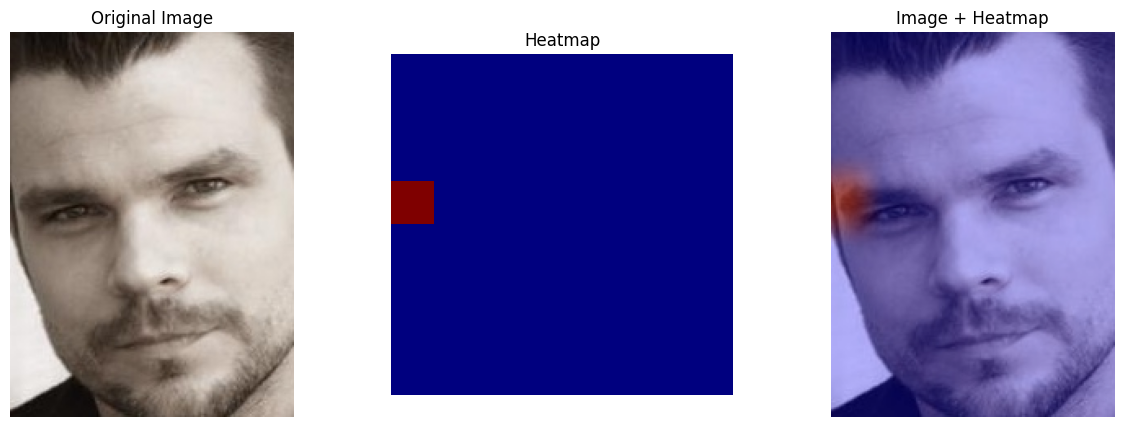

Is a Real Face (Confidence): 0.042990968


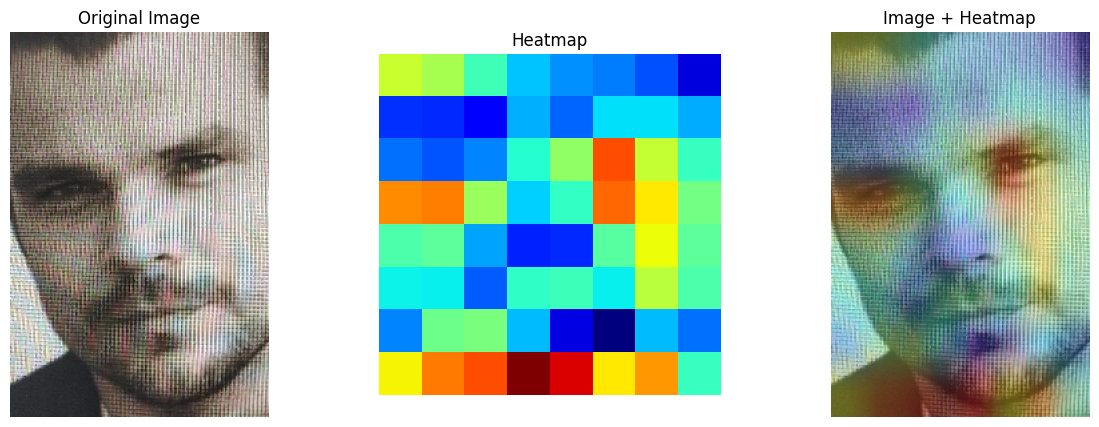

Is a Real Face (Confidence): 0.0019787052


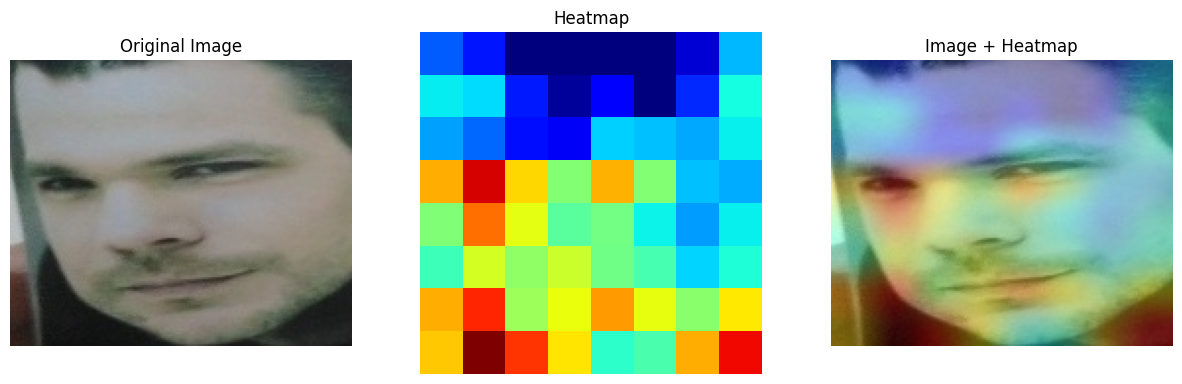

In [ ]:
np.random.seed(2024)
# Real Face
visual_feature('369707.jpg')
# Fake Face
visual_feature('240828.jpg')
# Fake Face
visual_feature('391118.jpg')

## Predict Time

In [ ]:
img_loaded = cv2.imread('240828.jpg')[:,:,::-1]
img = cv2.resize(img_loaded, (256,256))
img_to_model = np.expand_dims(img/255., axis=0)

In [ ]:
%%timeit
model.predict(img_to_model, verbose=0)

934 ms ± 254 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Probability Distribution

In [ ]:
%%time

np.random.seed(42)
tf.random.set_seed(42)

no_times=25
for i in tqdm.tqdm(range(no_times), total=no_times):
    predict = np.array(model.predict(img_to_model, verbose=0))

    predict_p = predict[:,:,1:]
    predict_n = predict[:,:,:1]
    if i==0:
        predict_test_array_p = predict_p.copy()
        predict_test_array_n = predict_n.copy()
    else:
        predict_test_array_p = np.concatenate([predict_test_array_p, predict_p], axis=-1)
        predict_test_array_n = np.concatenate([predict_test_array_n, predict_n], axis=-1)

100%|██████████| 25/25 [00:23<00:00,  1.08it/s]

CPU times: user 35.6 s, sys: 442 ms, total: 36 s
Wall time: 23.3 s


Real Face / Mean: 0.06475851684808731, Standard Deviation: 0.029185112565755844


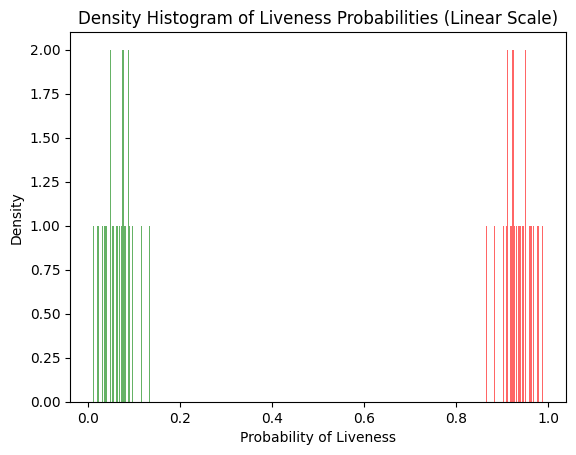

Fake Face / Mean: 0.9352415204048157, Standard Deviation: 0.029185110703110695


In [ ]:
predict_test_array = predict_test_array_p[4][0]
liveness_predictions = np.array(predict_test_array[:25])

plt.hist(liveness_predictions, bins=50, density=False, alpha=0.6, color='g')
plt.title('Density Histogram of Liveness Probabilities (Linear Scale)')
plt.xlabel('Probability of Liveness')
plt.ylabel('Density')
print(f"Real Face / Mean: {np.mean(liveness_predictions)}, Standard Deviation: {np.std(liveness_predictions)}")

predict_test_array = predict_test_array_n[4][0]
liveness_predictions = np.array(predict_test_array[:25])

plt.hist(liveness_predictions, bins=50, density=False, alpha=0.6, color='r')
plt.title('Density Histogram of Liveness Probabilities (Linear Scale)')
plt.xlabel('Probability of Liveness')
plt.ylabel('Density')

plt.show()
print(f"Fake Face / Mean: {np.mean(liveness_predictions)}, Standard Deviation: {np.std(liveness_predictions)}")

Real Face / Mean: 0.06475851684808731, Standard Deviation: 0.029185112565755844


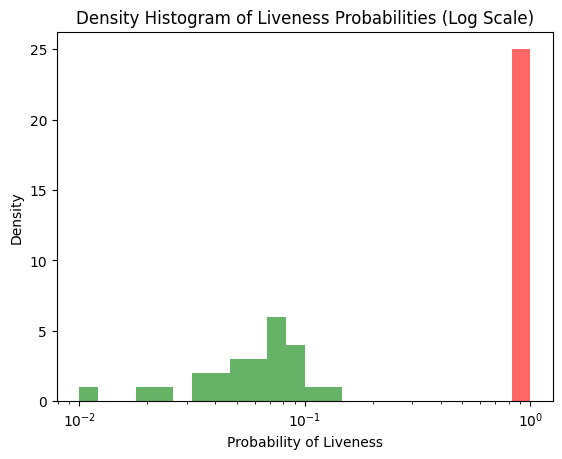

Fake Face / Mean: 0.9352415204048157, Standard Deviation: 0.029185110703110695


In [ ]:
ref_log = 2

predict_test_array = predict_test_array_p[4][0]
liveness_predictions = np.array(predict_test_array[:25])

plt.hist(liveness_predictions, bins=np.logspace(-ref_log, 0, 25), density=False, alpha=0.6, color='g')
plt.gca().set_xscale("log")
plt.title('Density Histogram of Liveness Probabilities (Log Scale)')
plt.xlabel('Probability of Liveness')
plt.ylabel('Density')
print(f"Real Face / Mean: {np.mean(liveness_predictions)}, Standard Deviation: {np.std(liveness_predictions)}")

predict_test_array = predict_test_array_n[4][0]
liveness_predictions = np.array(predict_test_array[:25])

plt.hist(liveness_predictions, bins=np.logspace(-ref_log, 0, 25), density=False, alpha=0.6, color='r')
plt.gca().set_xscale("log")
plt.title('Density Histogram of Liveness Probabilities (Log Scale)')
plt.xlabel('Probability of Liveness')
plt.ylabel('Density')

plt.show()
print(f"Fake Face / Mean: {np.mean(liveness_predictions)}, Standard Deviation: {np.std(liveness_predictions)}")

END